# Section 1 - Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Section 2 - Read data

In [2]:
df = pd.read_csv("cardekho.csv")

# Section 3 - Understand

In [4]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petrol            Manual    17.00    1197      80.00      5   
3  Individual    Petrol            Manual    20.92     998      67.10      5   
4      Dealer    Diesel            Manual    22.77    1498      98.59      5   

   selling_price  
0         120000  
1         550000  
2         2

# Section 4 - Data quality

In [6]:
print("Null values :",df.isnull().sum())
print("Duplicate values :", df.duplicated().sum())

Null values : Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64
Duplicate values : 0


# Section 5 - Cleaning

In [10]:
# Remove column unnamed 0
df["Unnamed: 0"].head()
df.drop("Unnamed: 0", axis=1, inplace=True)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
# Check data
df.head()

In [11]:
# Check invalid seats
df["seats"].value_counts().sort_index()
# There are 2 records where seats = 0, A car cannot realistically have zero seats, so these are invalid values.

,count
seats,
0,2
2,7
4,77
5,12910
6,127
7,1922
8,311
9,55


In [13]:
df[df["seats"] == 0]
# Since there are only two, we can remove them:
df = df[df["seats"] != 0]
# Check
df["seats"].value_counts().sort_index()

,count
seats,
2,7
4,77
5,12910
6,127
7,1922
8,311
9,55


In [ ]:
# Data type
# Numerical columns:
  # vehicle_age
  # km_driven
  # mileage
  # engine
  # max_power
  # seats
  # selling_price

# Categorical columns:
  # car_name
  # brand
  # model
  # seller_type
  # fuel_type
  # transmission_type

# Note: Our dataset already has appropriate types. So don't convert things unnecessarily.

# Section 6 - EDA

In [ ]:
# I'd divide EDA into four questions:
  # 1. What does the target look like?
  # 2. What do individual features look like?
  # 3. How do categories affect price?
  # 4. What numerical variables are related to price?

In [14]:
# Target variable — Selling Price
df["selling_price"].describe()

,selling_price
count,1.540900e+04
mean,7.749893e+05
std,8.941654e+05
min,4.000000e+04
25%,3.850000e+05
50%,5.560000e+05
75%,8.250000e+05
max,3.950000e+07


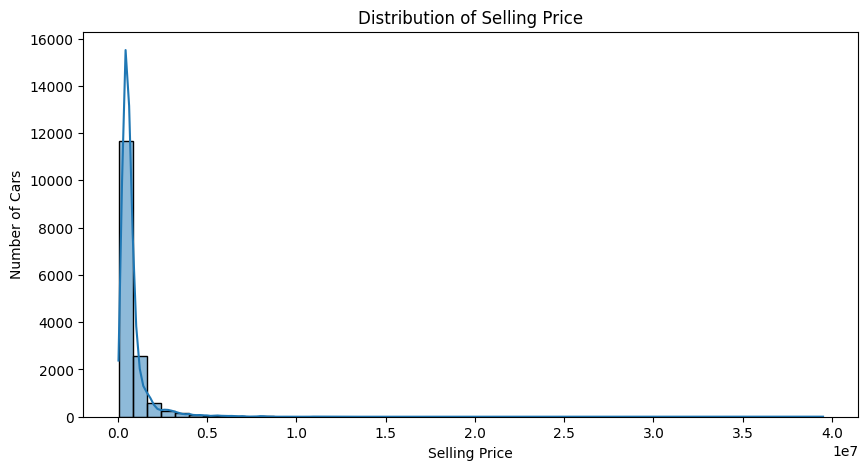

In [15]:
# Histogram plot for Distribution
plt.figure(figsize=(10, 5))

sns.histplot(data=df,x="selling_price",bins=50,kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

Important observation

- The selling price is strongly right-skewed.

- There are many cars at lower/mid prices and a small number of expensive luxury cars.

- For example, the dataset contains cars such as:
  - Ferrari
  - Rolls-Royce
  - Bentley
  - Porsche
  - Mercedes-Benz

- So do not automatically remove these as outliers.
They are legitimate cars.

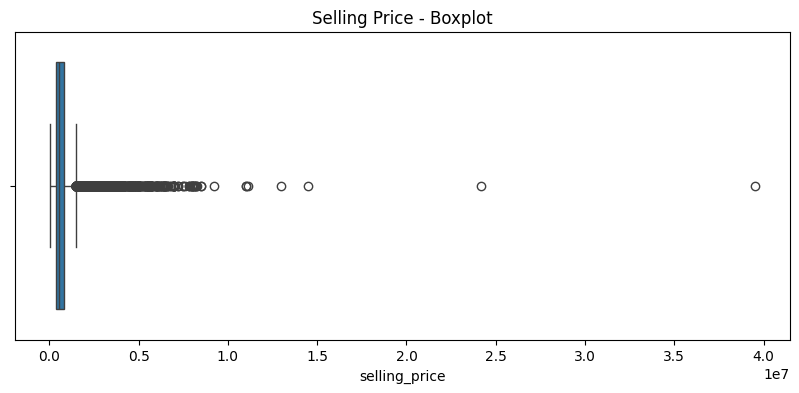

In [17]:
# Boxplot of selling price
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["selling_price"])
plt.title("Selling Price - Boxplot")
plt.show()

# Clearly see the extreme values. These are potentially high-value observations, not necessarily bad data.

# Section 7 - Visualization

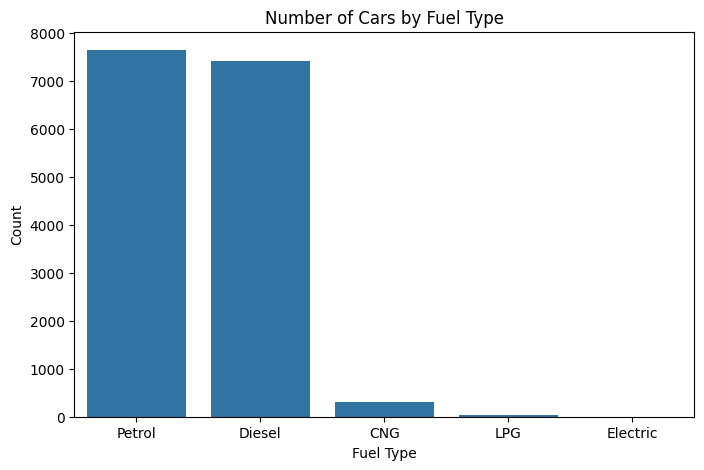

In [18]:
# Univariate Analysis
# Fuel Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df,x="fuel_type")
plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.show()
# Observation:
  # You should see Petrol and Diesel dominating the dataset.
  # Interestingly, there are only 4 Electric cars in this dataset.

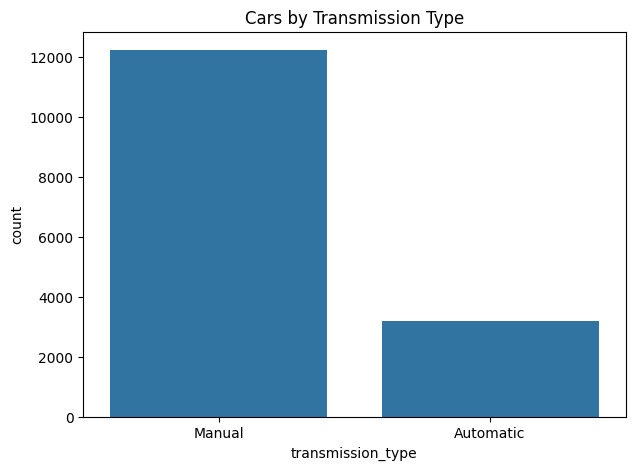

In [19]:
# Transmission
plt.figure(figsize=(7, 5))
sns.countplot(data=df,x="transmission_type")
plt.title("Cars by Transmission Type")

plt.show()

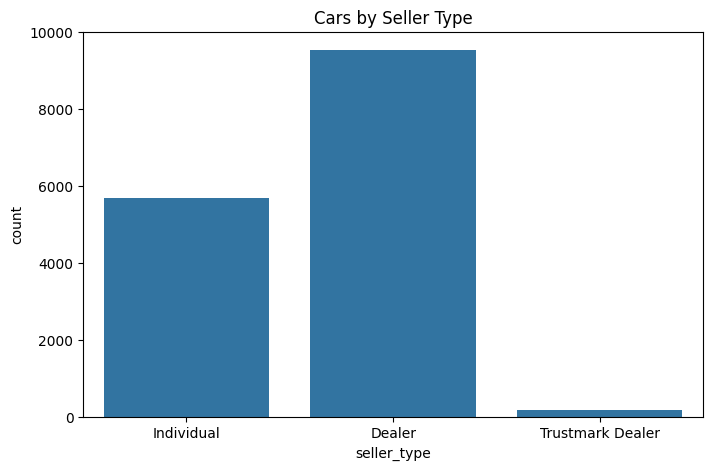

In [20]:
# Seller Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df,x="seller_type")
plt.title("Cars by Seller Type")

plt.show()

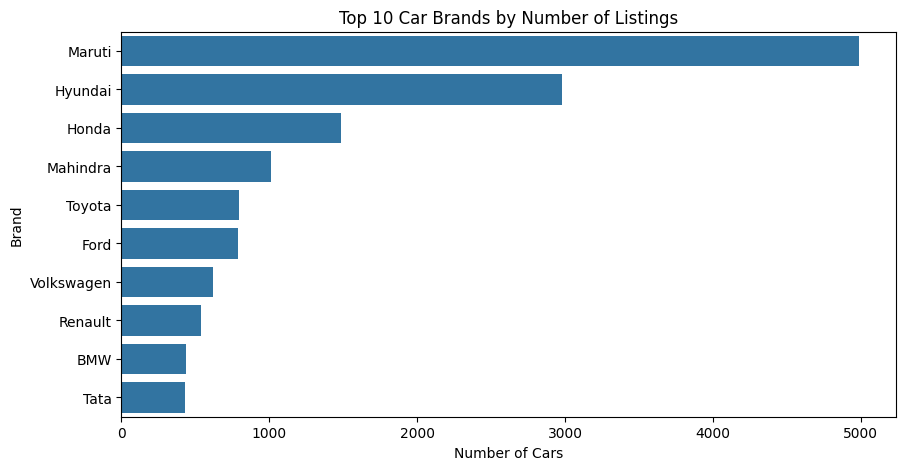

In [21]:
# Brand
brand_counts = df["brand"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=brand_counts.values,y=brand_counts.index)
plt.title("Top 10 Car Brands by Number of Listings")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")

plt.show()

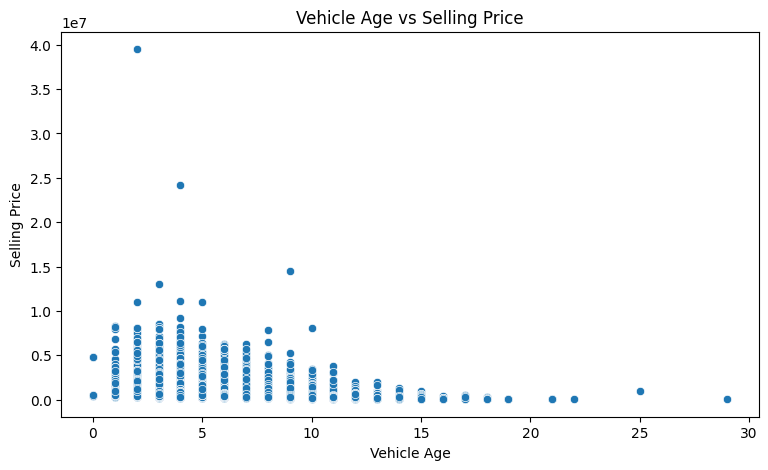

In [22]:
# Bivariate Analysis
# Vehicle Age vs Selling Price
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df,x="vehicle_age",y="selling_price")
plt.title("Vehicle Age vs Selling Price")
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")

plt.show()
# Observation:
  # Older vehicles tend to have lower selling prices.
  # But there will be variation because brand, engine, mileage, etc. also matter.

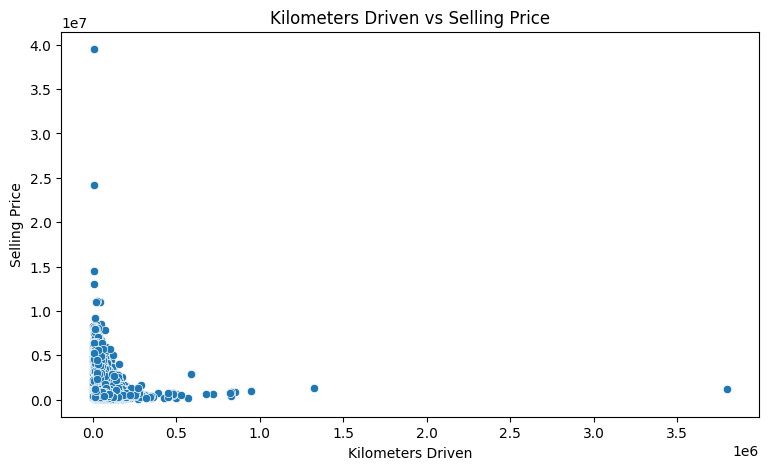

In [23]:
# Kilometer Driven vs Selling Price
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df,x="km_driven",y="selling_price")
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()
# Observation:
# Notice that a few extreme km_driven values stretch the graph.
# Values as high as 3.8 million km, while most observations are substantially lower.

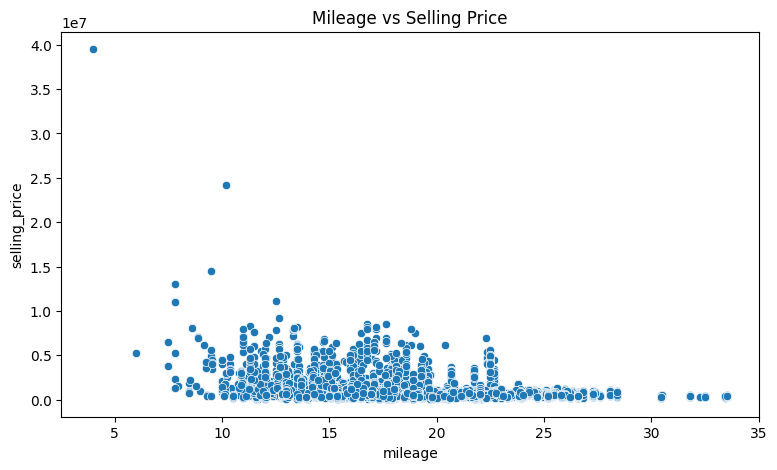

In [24]:
# Mileage vs Selling Price
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df,x="mileage",y="selling_price")
plt.title("Mileage vs Selling Price")

plt.show()

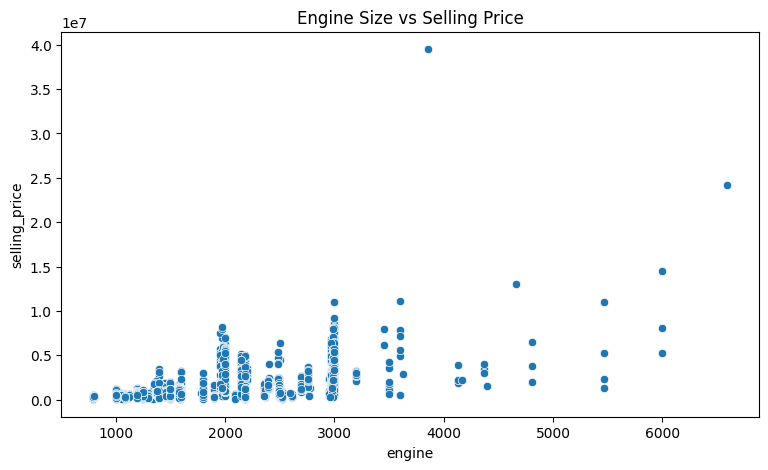

In [25]:
# Engine vs Selling Price
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df,x="engine",y="selling_price")
plt.title("Engine Size vs Selling Price")

plt.show()

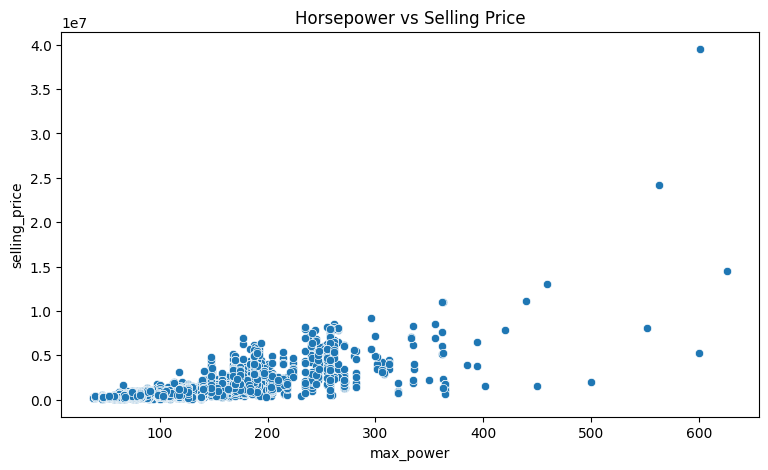

In [26]:
# Horsepower vs Selling Price
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df,x="max_power",y="selling_price")
plt.title("Horsepower vs Selling Price")

plt.show()

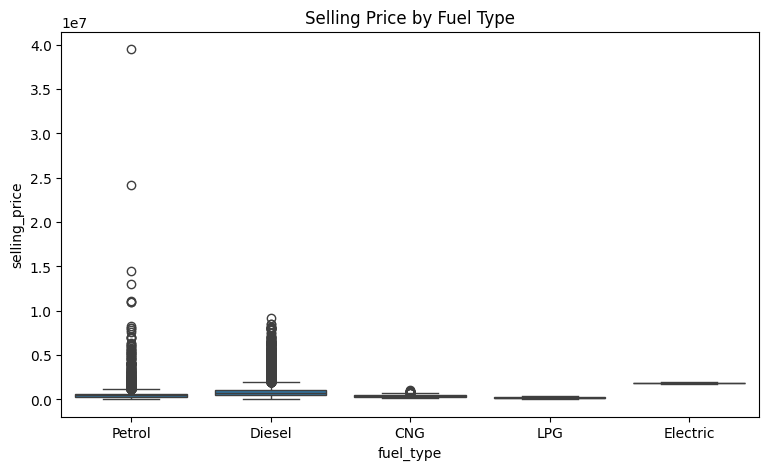

In [27]:
# =================Categorical vs Selling Price ==================================
# Fuel Type vs Selling Price
plt.figure(figsize=(9, 5))
sns.boxplot(data=df,x="fuel_type",y="selling_price")
plt.title("Selling Price by Fuel Type")

plt.show()

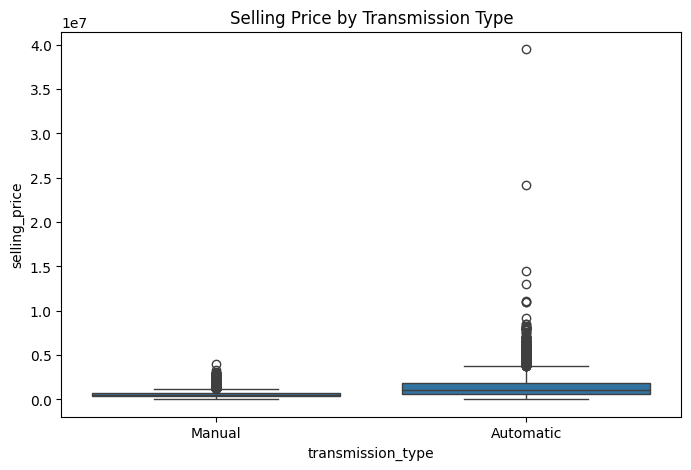

In [28]:
# Transmission vs Selling Price
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x="transmission_type",y="selling_price")
plt.title("Selling Price by Transmission Type")
plt.show()

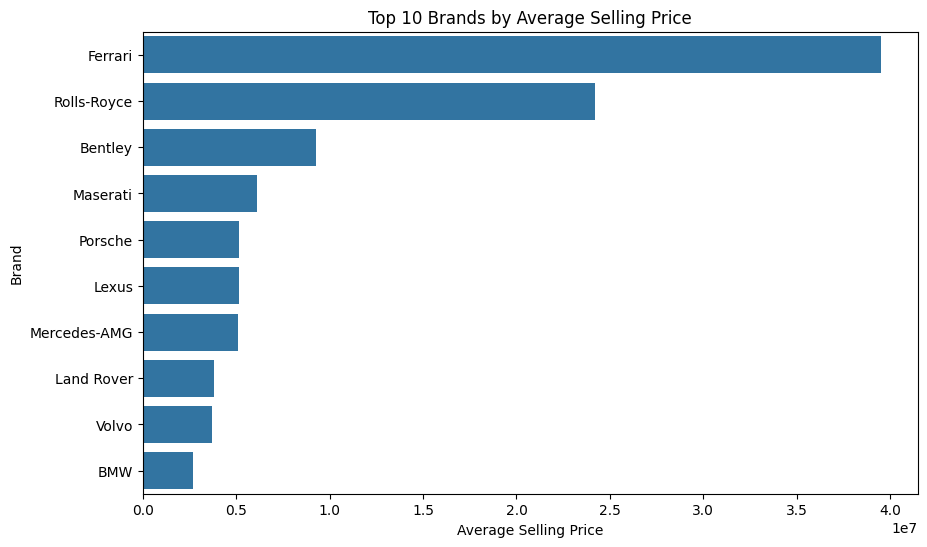

In [29]:
# Brand vs Selling Price
# There are 32 brands, so use the top brands by average price rather than putting all 32 on one graph.
brand_price = (df.groupby("brand")["selling_price"].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 6))
sns.barplot(x=brand_price.values,y=brand_price.index)
plt.title("Top 10 Brands by Average Selling Price")
plt.xlabel("Average Selling Price")
plt.ylabel("Brand")

plt.show()

In [30]:
# Correlation Analysis
# select numerical columns:
numeric_cols = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "selling_price"
]

corr = df[numeric_cols].corr()

In [31]:
# display
print(corr)

               vehicle_age  km_driven   mileage    engine  max_power  \
vehicle_age       1.000000   0.334092 -0.257155  0.099014   0.005231   
km_driven         0.334092   1.000000 -0.105287  0.192888   0.044433   
mileage          -0.257155  -0.105287  1.000000 -0.633039  -0.533174   
engine            0.099014   0.192888 -0.633039  1.000000   0.807370   
max_power         0.005231   0.044433 -0.533174  0.807370   1.000000   
seats             0.032026   0.192873 -0.442286  0.552783   0.172818   
selling_price    -0.241768  -0.080025 -0.305657  0.585859   0.750249   

                  seats  selling_price  
vehicle_age    0.032026      -0.241768  
km_driven      0.192873      -0.080025  
mileage       -0.442286      -0.305657  
engine         0.552783       0.585859  
max_power      0.172818       0.750249  
seats          1.000000       0.115227  
selling_price  0.115227       1.000000  


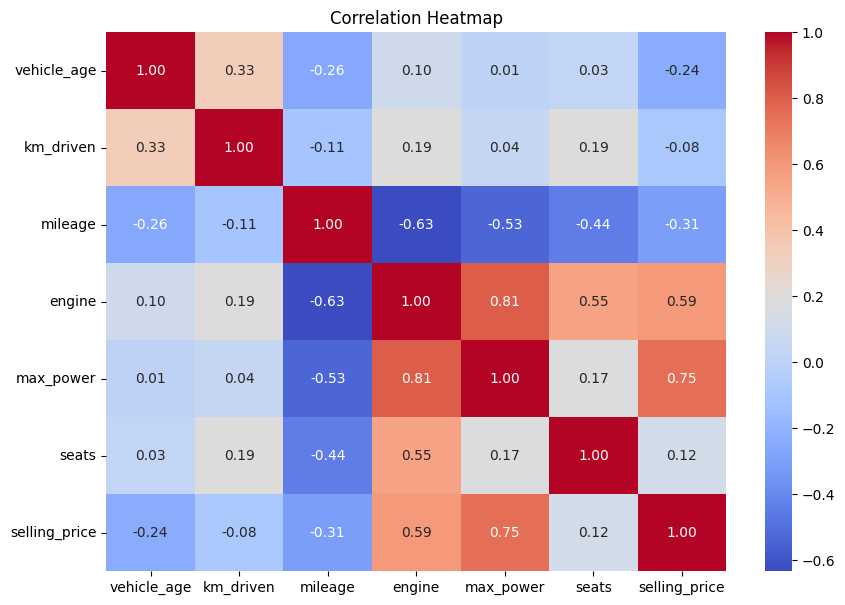

In [32]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")

plt.show()
# +1 → strong positive relationship
#  0 → little/no linear relationship
# -1 → strong negative relationship

# For our project, pay particular attention to:

  # selling_price ↔ vehicle_age
  # selling_price ↔ km_driven
  # selling_price ↔ engine
  # selling_price ↔ max_power

In [ ]:
# Feature Selection
# This is where we start transitioning from EDA → Machine Learning.

# We have:

  # car_name
  # brand
  # model
  # vehicle_age
  # km_driven
  # seller_type
  # fuel_type
  # transmission_type
  # mileage
  # engine
  # max_power
  # seats
  # selling_price

# I would not use all of them.

# Drop: car_name, model
# Because: car_name and model have high cardinality and overlap heavily with brand.

In [ ]:
# We'll keep:

  # brand
  # vehicle_age
  # km_driven
  # seller_type
  # fuel_type
  # transmission_type
  # mileage
  # engine
  # max_power
  # seats

# Target: selling_price

# Section 8 - Save cleaned dataset

In [33]:
df.to_csv("cleaned_cars.csv", index=False)
# File has saved to colab and download it to local machine